### **2017 Telemetry; see ``new_rtc_telemetry.ipynb`` for new RTC telemetry analysis** 
(as of 02/11/2025, only telemetry from 20240807 has been downloaded & analyzed so far)

#### **Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import readsav
from pathlib import Path
import maos_utils as mu
from astropy.io import fits
import pandas as pd

#### **Load LGS telemetry files**
##### and pull/calculate necessary information, rather than storing entire ``data`` object

``STRAPDQMN`` : one number for entire night of observation/telemetry. Provided in FITS image header and telemetry data.header. Units in KAON are "quad mean apd counts"
* compare to *input* ``powfs.siglev`` for ``STRAP``

``LGRMSWF``   : one number for entire night of observation/telemetry. Provided in FITS image header and telemetry data.header. Units are nm
* compare to *output* ``MAOS HO WFE``

``STINTTIM`` : ``STRAP`` integration times, one setting for entire night of observation. Provided in FITS image header and telemetry data.header. Units are ms
* compare to ``data.b.timestamps[0]`` interval/spacing

``WSFRRT``    : ``SHWFS`` frame rate, one setting for entire night of observation. Provided in FITS image header and telemetry data.header. Units are in Hz
* compare to ``data.a.timestamps[0]`` interval/spacing after converting to milli-seconds (like ``STRAP``)

``APDCOUNTS`` : [4, # of timestamps] array for night of observation. 4 refers to 4 WFS quadrants. Units are in counts.
* Average over all 4 quadrants over night to get one number per night/telemetry file --> compare this to ``STRAPDQMN`` using gain settings
* ``APD_SKY_BACK`` is [1, 4] array for night of observation. 4 refers to 4 WFS quadrants. Units are **unclear**. Based on shape of data array, I think this is the background for each WFS quadrant for the entire night (one quantity per quadrant per telemetry file)
* compare calculated ``APDCOUNTS`` using expected relationship with ``STRAPDQMN`` (telemetry ``data`` header quantity) versus ``APDCOUNTS`` from telemetry ``data``

``SUBAPINTENSITY`` : [304, # of timestamps] array for night of observation. 304 refers to 304 sub-apertures. Units are in adu.
* compare to *input* ``powfs.siglev`` for ``SHWFS``

``RESIDUALRMS`` : [# of timestamps] array for night of observation. Units are in nm.
* Average over entire timestream for one quantity per night/telemetry file



In [38]:
telemetry = mu.telemetry_data()

Telemetry file 1 out of 2294 | /g/lu/data/keck_telemetry/20170718/sdata901/nirc15/2017jul18/n0098_LGS_trs.sav
Assumptions:
  Wave-Front Sensor       = LGSWFS
  Pupil Aperture Diameter = 0.56 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 3.000 arcsec/pix
  Spot Size Diameter      = 1.500 arcsec
  Filter                  = R
  Readnoise               = 6.5 e-
  Pixels per Subaperture  = 4
  Integration Time        = 0.0010 s
  Guide Star Magnitude    = 8.10

Outputs:
  N_photons from star (powfs.siglev for MAOS config): 600.357
  N_photons per pixel from background (powfs.bkgrnd):   0.071
  SNR:                                   21.640
  NEA (powfs.nearecon): 69.315 mas
Assumptions:
  Wave-Front Sensor       = STRAP
  Pupil Aperture Diameter = 9.57 m (assumed square)
  Throughput (w QE)       = 0.32
  Plate Scale             = 1.300 arcsec/pix
  Spot Size Diameter      = 0.490 arcsec
  Filter                  = R
  Readnoise               = 0.1 e-
  Pixe

In [2]:
# Read in telemetry CSV that already exists for all dates (06/24/2024)
columns = (['filename', 'LGRMSWFs', 'STRAPDQMNs', 'SUBAPINTs [adu]', 
            'STINTTIMs', 'DATA.B Time Interval',
            'SHWFS int times', 'DATA.A Time Interval',
            'APDCOUNTS', 'APD_SKY_BACK',
            'SHWFS FLUX',
            'RESIDUALRMS', 'RMSWFE', 
            'STRAP SIGLEV', 'STRAP BKGRND', 
            'SHWFS SIGLEV', 'SHWFS BKGRND'])
telemetry = pd.read_csv("/Users/bdigia/work/ao/keck/maos/keck/my_base/LGS_telemetry.csv", 
                        names=columns, header=0)

In [3]:
telemetry

,filename,LGRMSWFs,STRAPDQMNs,SUBAPINTs [adu],STINTTIMs,DATA.B Time Interval,SHWFS int times,DATA.A Time Interval,APDCOUNTS,APD_SKY_BACK,SHWFS FLUX,RESIDUALRMS,RMSWFE,STRAP SIGLEV,STRAP BKGRND,SHWFS SIGLEV,SHWFS BKGRND
0,/g/lu/data/keck_telemetry/20170718/sdata901/ni...,641.5,401476.25,1338.280029,1.0,1.000048,1.000000,1.000354,356.284088,0.000,679.846191,32.026787,127.078396,765.062927,3.904666,600.356908,0.071228
1,/g/lu/data/keck_telemetry/20170718/sdata901/ni...,91.8,348761.50,1350.475220,1.0,1.000048,1.000000,1.000354,355.873596,0.000,686.041565,31.858028,123.194468,765.062927,3.904666,600.356908,0.071228
2,/g/lu/data/keck_telemetry/20170718/sdata901/ni...,571.0,63816.25,1206.427979,2.0,2.000096,1.000000,1.000354,125.272354,4.230,612.865540,60.508865,175.804943,1530.125855,7.809331,600.356908,0.071228
3,/g/lu/data/keck_telemetry/20170718/sdata901/ni...,306.9,61165.00,1246.703857,2.0,2.000096,1.000000,1.000354,123.607063,4.230,633.325439,47.708454,127.578163,1530.125855,7.809331,600.356908,0.071228
4,/g/lu/data/keck_telemetry/20170718/sdata901/ni...,253.0,61364.75,973.376160,2.0,2.000096,1.000000,1.000354,108.083862,4.230,494.475464,72.692169,168.306416,1530.125855,7.809331,600.356908,0.071228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2289,/g/lu/data/keck_telemetry/20170826/sdata903/ni...,120.5,10024.75,3080.103271,8.0,8.000384,2.272727,2.272652,79.154915,11.232,688.465210,19.277206,93.018240,6120.503420,31.237326,1364.447518,0.161882
2290,/g/lu/data/keck_telemetry/20170826/sdata903/ni...,212.1,10205.25,3122.770020,8.0,8.000384,2.272727,2.272652,81.410599,11.232,698.001343,25.038546,96.656173,6120.503420,31.237326,1364.447518,0.161882
2291,/g/lu/data/keck_telemetry/20170826/sdata903/ni...,124.3,10924.50,3132.375977,8.0,8.000384,2.272727,2.272652,85.771461,11.232,700.149353,31.659285,96.740153,6120.503420,31.237326,1364.447518,0.161882
2292,/g/lu/data/keck_telemetry/20170826/sdata903/ni...,158.3,10776.00,3114.297119,8.0,8.000384,2.272727,2.272652,85.240746,11.232,696.107666,31.681385,96.373075,6120.503420,31.237326,1364.447518,0.161882


#### **STRAP APDCOUNT plots**

In [4]:
# STRAP parameters
band = "R"
# Keck telescope diameter (m)
D = 10.949
# Secondary obscuration diameter (m)
Ds = 1.8
side = np.sqrt( np.pi * ( (D  / 2.0)**2 - (Ds / 2.0)**2 ) )
throughput = 0.32
ps = 1.4
m = 14
sigma_e = 0.0

In [5]:
nstars = []
nbs = []
for time in telemetry['STINTTIMs']:
    time /= 1000.0 # convert time from ms to s
    # Fixed parameters
    c = 2.99792458e8   # Speed of light (m s^-1)
    h = 6.6260755e-27  # Plank constant (erg s)
    # Bands' names, effective wavelengths (microns), equivalent widths
    # (microns), fluxes (10^-11 erg s^-1 cm^-2 A^-1) and background
    # in (magnitudes arcsec^-2) [1, 2, 3].
    bands = {'name': ["U", "B", "V", "R", "I", "J", "H", "K"],
             'lambd': [0.366, 0.438, 0.545, 0.641, 0.798, 1.22, 1.63, 2.19],
             'delta_lambd': [0.0665, 0.1037, 0.0909, 0.1479, 0.1042, 0.3268, 
                             0.2607, 0.5569],
             'phi_erg': [417.5, 632, 363.1, 217.7, 112.6, 31.47, 11.38, 3.961],
             'bkg_m': [21.6, 22.3, 21.1, 20.3, 19.2, 14.8, 13.4, 12.6]}
    # Get band's data
    band_idx = np.where(np.array(bands['name']) == band)[0][0]
    # Band effective wavelength (microns)    
    lambd = float(bands['lambd'][band_idx])
    # Band equivalent width (microns)
    delta_lamb = float(bands['delta_lambd'][band_idx])
    # Flux (erg s^-1 cm^-2 A^-1)
    phi_erg = float(bands['phi_erg'][band_idx])
    # Background magnitude (arcsec^-2)    
    bkg_m = float(bands['bkg_m'][band_idx])
    # Band frequency (Hz)
    f = c / (lambd * 1e-6)
    # Numeric flux (s^-1 cm^-2 A^-1)
    phi_n = (phi_erg * 1e-11) / ( h * f )
    # Zeropoint (m = 0) number of photons on detector
    n_ph_0 = phi_n * ( (side * 1e2) ** 2) * time * delta_lamb * 1e4 * throughput
    # Number of star photons
    n_ph_star = n_ph_0 * ( 10**(-0.4 * m ))
    # print(f"Number of star photons on STRAP at integration time = {n_ph_star*0.3:.3f} photons per subaperture") 
    # Number of background photons (px^-1)
    n_ph_bkg = n_ph_0 * ( 10**(-0.4 * bkg_m) ) * (ps)**2.0 
    # print(f"Number of background photons on STRAP at integration time = {n_ph_bkg*0.3:.3f} background photons per pixel")
    nstars.append(n_ph_star)
    nbs.append(n_ph_bkg)

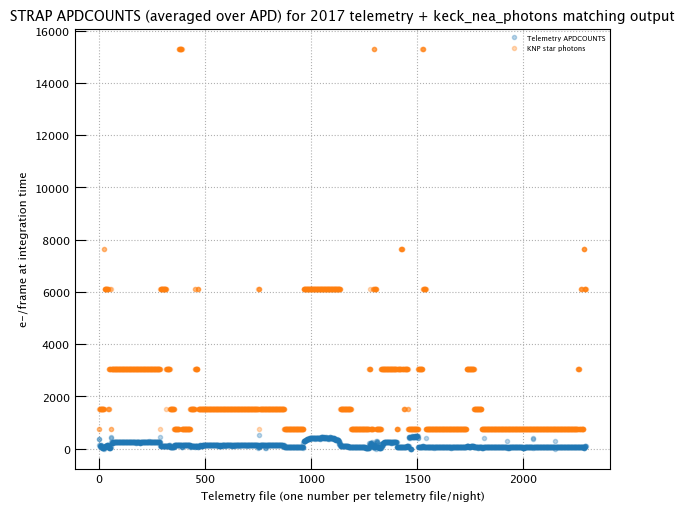

In [6]:
fig = plt.figure(figsize=(6.0, 5.0), layout='constrained')
plt.plot(telemetry['APDCOUNTS'], '.', label="Telemetry APDCOUNTS", linewidth=0.2, alpha=0.3)
plt.plot(nstars, '.', label="KNP star photons", linewidth=0.2, alpha=0.3)
# plt.plot(telemetry['APD_SKY_BACK'], '.', label="Telemetry APD bkgrnd")
# plt.plot(nbs, '.', label="KNP bkgrnd photons")
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Telemetry file (one number per telemetry file/night)", fontsize=8.0)
plt.ylabel("e-/frame at integration time", fontsize=8.0)
plt.title("STRAP APDCOUNTS (averaged over APD) for 2017 telemetry + keck_nea_photons matching output", fontsize=10.0)
plt.legend(frameon=False, fontsize=5)
plt.gca().tick_params(axis='both', direction='in', labelsize=8.0)

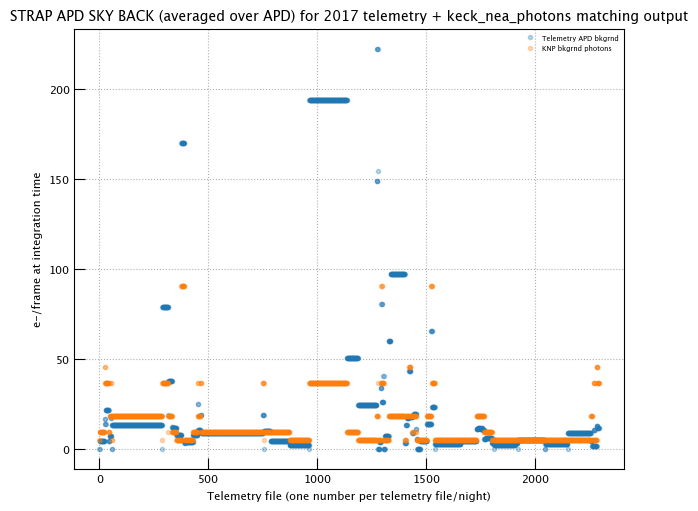

In [7]:
fig = plt.figure(figsize=(6.0, 5.0), layout='constrained')
plt.plot(telemetry['APD_SKY_BACK'], '.', label="Telemetry APD bkgrnd", linewidth=0.2, alpha=0.3)
plt.plot(nbs, '.', label="KNP bkgrnd photons", linewidth=0.2, alpha=0.3)
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Telemetry file (one number per telemetry file/night)", fontsize=8.0)
plt.ylabel("e-/frame at integration time", fontsize=8.0)
plt.title("STRAP APD SKY BACK (averaged over APD) for 2017 telemetry + keck_nea_photons matching output", fontsize=10.0)
plt.legend(frameon=False, fontsize=5)
plt.gca().tick_params(axis='both', direction='in', labelsize=8.0)

In [3]:
# telemetry.to_csv("/Users/bdigia/work/ao/keck/maos/keck/my_base/LGS_telemetry_dm_flat.csv", index=False)
telemetry.to_csv("/Users/bdigia/work/ao/keck/maos/keck/my_base/LGS_telemetry_residualwavefront.csv", index=False)

#### **Subaperture-actuator map, colored by subaperture intensities or SNR**

In [43]:
data = readsav(telemetry['filename'][2279])
cx = data.a.offsetcentroid[0][:,::2]
cy = data.a.offsetcentroid[0][:,1::2]
# Standard deviation
sigma_x = np.std(np.abs(cx), axis=0)
sigma_y = np.std(np.abs(cy), axis=0)
# SNR = theta (spot size) / sigma_arcsec
spot = 1.93
SHWFS_SNR_KAON422_x = spot / sigma_x
SHWFS_SNR_KAON422_y = spot / sigma_y
print(SHWFS_SNR_KAON422_x)
print(SHWFS_SNR_KAON422_y)
print(np.mean([SHWFS_SNR_KAON422_x, SHWFS_SNR_KAON422_y]))
mean_over_time = np.mean([SHWFS_SNR_KAON422_x, SHWFS_SNR_KAON422_y], axis=0)

[ 8.209184   9.621131   8.884388  22.18587   24.714514  15.082454
 15.674394  10.982452  30.381298  33.717785  24.445726  24.891615
 29.209902  27.297878   9.14907    7.5157    18.863586  21.043375
 23.714218  22.902132  22.855173  25.459433  21.995863  22.909044
 35.822136  36.429485  32.148884  16.4027     7.321767   6.7502418
 30.999357  35.41568   28.189394  23.08221   37.39109   37.571587
 24.985939  40.24287   36.58619   26.303858  28.410755  24.97541
 37.72636    8.483066   7.058282   6.2891536 29.566055  29.993263
 32.95547   35.15835   22.439272  25.247152  22.89579   25.47883
 33.145924  28.855001  33.238308  28.331354  36.488823  22.441225
 16.212397   6.429976  16.26321   37.345165  28.679735  32.050343
 32.744976  25.07014   37.116325  23.59481   37.591408  33.237873
 27.688005  24.371151  25.036896  24.541079  26.485518  23.972134
  7.957854   6.113227  35.009518  37.421574  24.164558  27.964655
 27.435417  37.393963  35.971275  41.660503  24.364725  23.354027
 22.692822 

In [49]:
subapint_mean = np.mean(data.a.subapintensity[0][:,].astype(float)*0.508, axis=0)
print(np.mean(subapint_mean))

1507.46427853395


[1 1 0 ... 0 1 1]
[[1 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 1]]
349


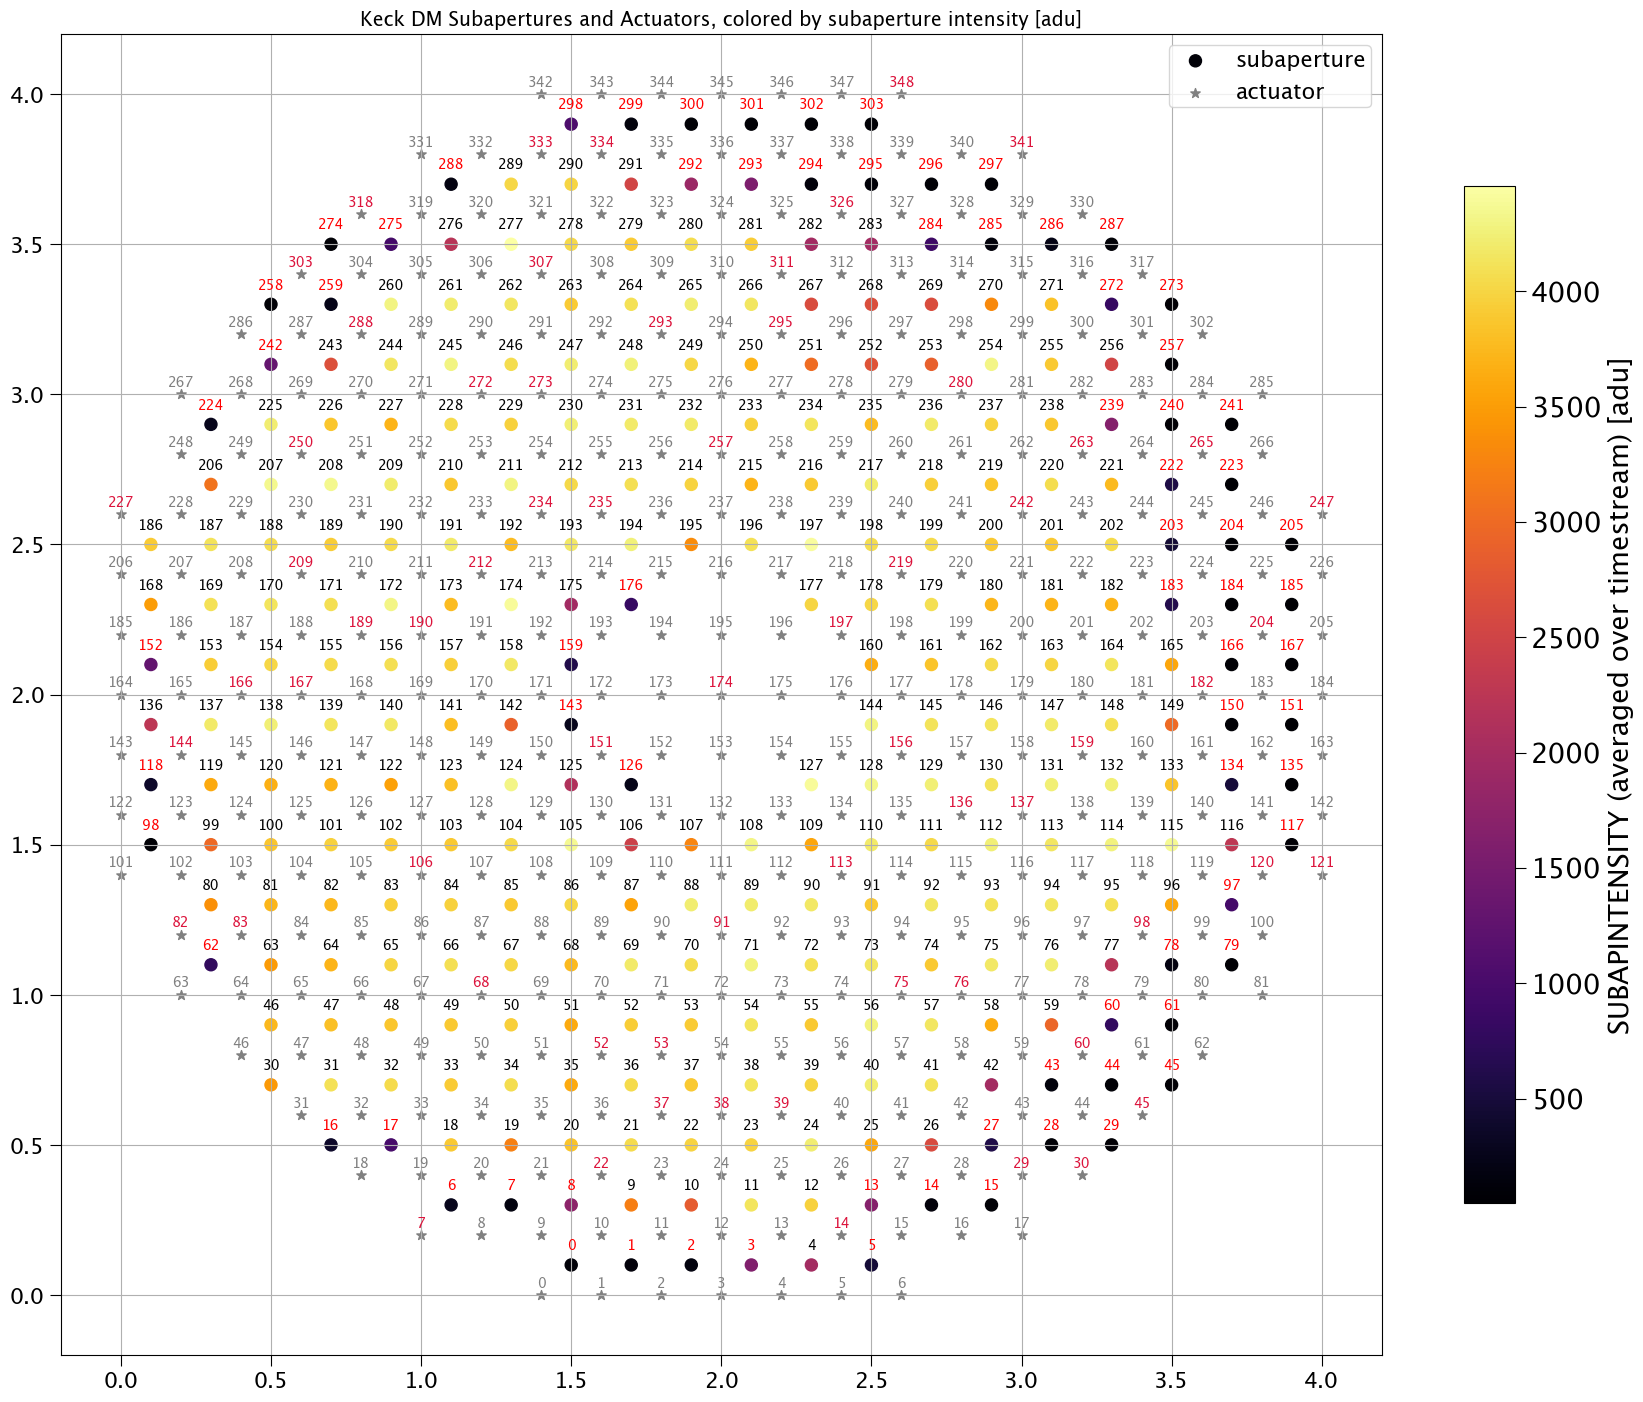

(array([  0,   1,   2,   3,   5,   6,   7,   8,  13,  14,  15,  16,  17,
         27,  28,  29,  43,  44,  45,  60,  61,  62,  78,  79,  97,  98,
        117, 118, 126, 134, 135, 143, 150, 151, 152, 159, 166, 167, 176,
        183, 184, 185, 203, 204, 205, 222, 223, 224, 239, 240, 241, 242,
        257, 258, 259, 272, 273, 274, 275, 284, 285, 286, 287, 288, 292,
        293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303]),
 array([2, 4, 4, 4, 2, 2, 4, 0, 4, 3, 4, 4, 2, 4, 0, 1, 4, 4, 2, 3, 3, 4,
        0, 4, 4, 4, 4, 4, 2, 0, 0, 2, 4, 2, 3, 4, 1, 0, 0, 0, 4, 3, 3, 4,
        2, 0, 2, 1, 4, 4, 4, 3, 0, 0, 4, 3, 3, 4, 4, 4, 0, 2, 4, 2, 4, 4,
        4, 2, 0, 3, 4, 2, 3, 4, 2, 0, 0, 1, 4, 3, 4, 4, 0, 0, 2, 2, 3, 4,
        4, 4, 1, 0, 4, 4, 3, 4, 3, 2, 0, 1, 4, 2, 4, 4, 3, 2, 0, 2, 4, 3,
        3, 4, 4, 0, 2, 2, 4, 3, 3, 4, 0, 0, 2, 2, 4, 4, 4, 4, 1, 1, 4, 3,
        3, 4, 3, 2, 0, 0, 4, 3, 3, 4, 2, 2, 0, 3, 4, 3, 3, 4, 3, 0, 2, 2,
        4, 4, 0, 4, 1, 0, 3, 4, 4, 3, 2, 2, 0, 0, 2,

In [33]:
mu.examine_subapertures(telemetry['filename'][2279])

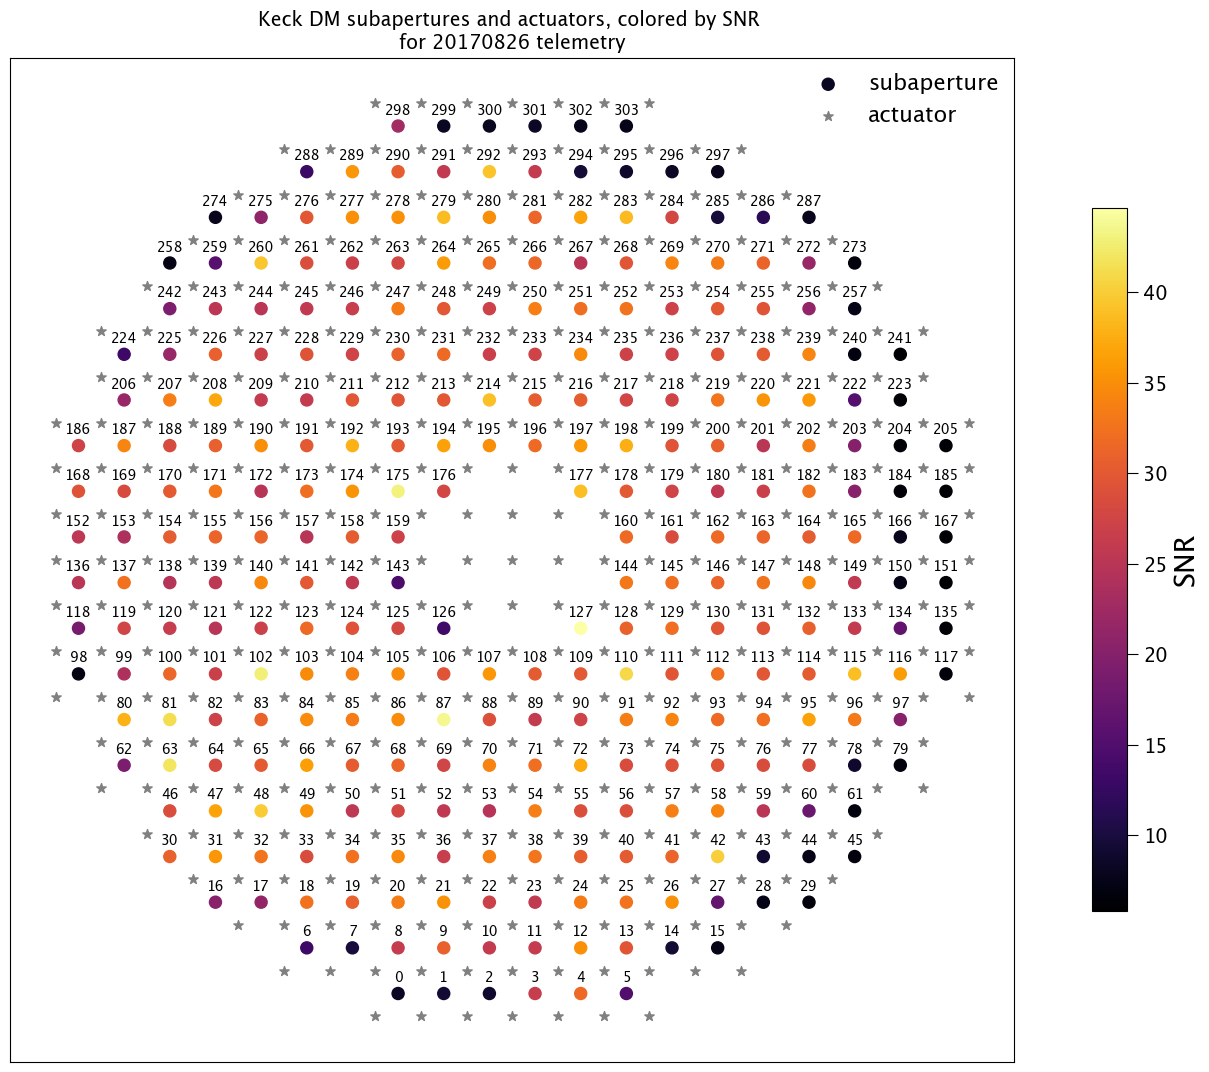

In [46]:
subap_map="/Users/bdigia/code/python/paarti/paarti/utils/sub_ap_map.txt"
actuator_map="/Users/bdigia/code/python/paarti/paarti/utils/actuator_map.txt"
import matplotlib as mpl
subapint_mean = np.mean(data.a.subapintensity[0][:,].astype(float)*0.508, axis=0)
with open(subap_map, 'r') as sub_aperture_map:
    with open(actuator_map, 'r') as actuator_map:
        exact_x = []
        exact_y = []
        start_y = 0.1
        act_x = []
        act_y = []
        start_act_y = 0.0
        for info in sub_aperture_map.readlines():
            start_x = 0.1
            line = list(info)
            for i in line:
                if (i != " ") & (i != '\n'):
                    if int(i) != 0:
                        exact_x.append(start_x)
                        exact_y.append(start_y)
                    start_x += 0.2
            start_y += 0.2
        for info in actuator_map.readlines():
            start_x = 0.0
            line = list(info)
            for i in line:
                if (i != " ") & (i != '\n'):
                    if int(i) != 0:
                        act_x.append(start_x)
                        act_y.append(start_act_y)
                    start_x += 0.2
            start_act_y += 0.2
        cmap = mpl.cm.inferno
        str_txt = [str(i) for i in range(304)]
        fig, axes = plt.subplots(figsize=(16.0, 11.0))
        im = plt.scatter(exact_x, exact_y, label="subaperture", alpha=1.0, 
                         c=pd.Series(mean_over_time), cmap=cmap, s=75)
        axes.set_aspect('equal')
        axes.xaxis.set_ticklabels([])
        axes.xaxis.set_ticks([])
        axes.yaxis.set_ticklabels([])
        axes.yaxis.set_ticks([])
        fig.colorbar(im, ax=axes, 
                     label=r'SNR', 
                     shrink=0.7)
        i = 0
        while i < 304:
            # if i in bad_subap:
            #     axes.text(exact_x[i], exact_y[i]+0.05, str_txt[i], 
            #               horizontalalignment='center', fontsize=10, color="red")
            # else:
            axes.text(exact_x[i], exact_y[i]+0.05, str_txt[i], horizontalalignment='center', fontsize=10, color="black")
            i += 1
        cbar = plt.gcf()
        cbar_ax = cbar.axes[-1]
        cbar_ax.tick_params(labelsize=14)
        cbar_ax.set_frame_on(True)
        plt.scatter(act_x, act_y, color="grey", label="actuator", alpha=1.0, marker="*", s=50)
        axes.set_title("Keck DM subapertures and actuators, colored by SNR \nfor 20170826 telemetry", 
                       fontsize=14)
        plt.legend(frameon=False)
        plt.grid(True, linestyle='dotted')
        plt.tight_layout()
        plt.show()

#### **Display ``telemetry`` dataframe**

>> ``telemetry.style`` for no row truncation and nice styling, though large output

In [6]:
telemetry['filename'][0]

'/g/lu/data/keck_telemetry/20170718/sdata901/nirc15/2017jul18/n0098_LGS_trs.sav'

In [7]:
data = readsav('/g/lu/data/keck_telemetry/20170718/sdata901/nirc15/2017jul18/n0098_LGS_trs.sav')

#### **Validate telemetry rate with SHWFS / STRAP integration times from FITS header & ``data.header``**

In [41]:
plt.rcParams.update({
    "text.usetex": False, # turn off latex rendering
    "font.sans-serif": "Helvetica",
})

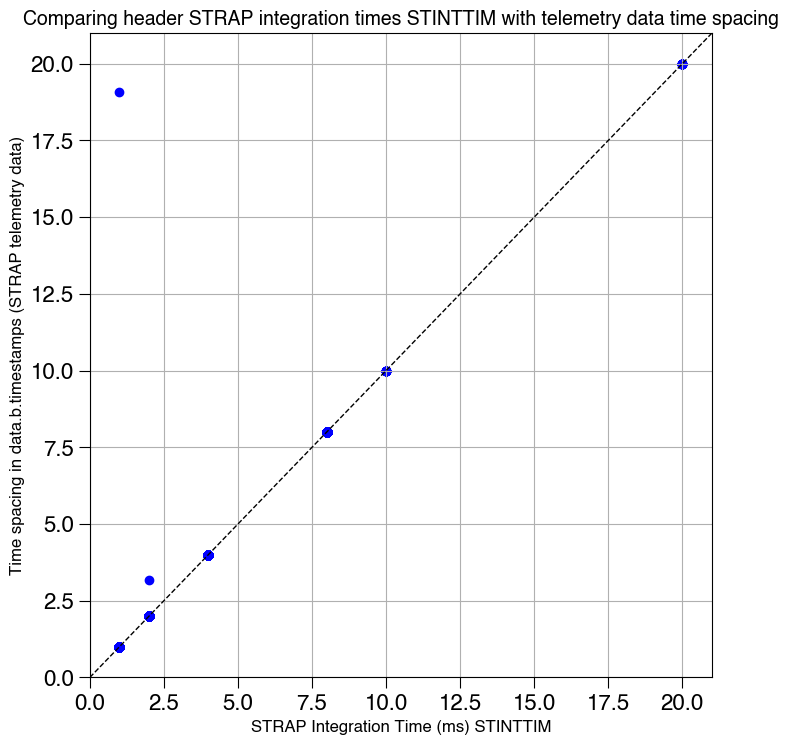

In [42]:
stinttims = telemetry['STINTTIMs'].astype(float)
data_b_intervals = telemetry['DATA.B Time Interval'].astype(float)

fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(stinttims, data_b_intervals, color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.ylim(0.0, 21.0)
plt.xlim(0.0, 21.0)
plt.xlabel("STRAP Integration Time (ms) STINTTIM", fontsize=12)
plt.ylabel("Time spacing in data.b.timestamps (STRAP telemetry data)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.title("Comparing header STRAP integration times STINTTIM with telemetry data time spacing", fontsize=14)
plt.show()

In [43]:
telemetry[telemetry['STINTTIMs'].astype(float) != round(telemetry['DATA.B Time Interval'].astype(float), 1)]

,filename,LGRMSWFs,STRAPDQMNs,SUBAPINTs [adu],STINTTIMs,DATA.B Time Interval,SHWFS int times,DATA.A Time Interval,APDCOUNTS,APD_SKY_BACK,SHWFS FLUX,RESIDUALRMS,RMSWFE,STRAP SIGLEV,STRAP BKGRND,SHWFS SIGLEV,SHWFS BKGRND
316,/g/lu/data/keck_telemetry/20170505/sdata901/ni...,300.0,23172.75,41.68668746948242,2.0,3.1800270440251577,1.3333333333333333,1.3335585324947592,106.17269134521484,18.856000900268555,15.882623672485352,5142.5029296875,1753.8315296173096,1530.1258549607142,7.809331491723155,800.4758772539054,0.09497094473176294
1306,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,300.0,0.0,6527.693359375,1.0,19.08278066352838,1.0,1.0003540994300983,0.5544235110282898,0.0,3316.068603515625,1.6351714134216309,22.052398324012756,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221


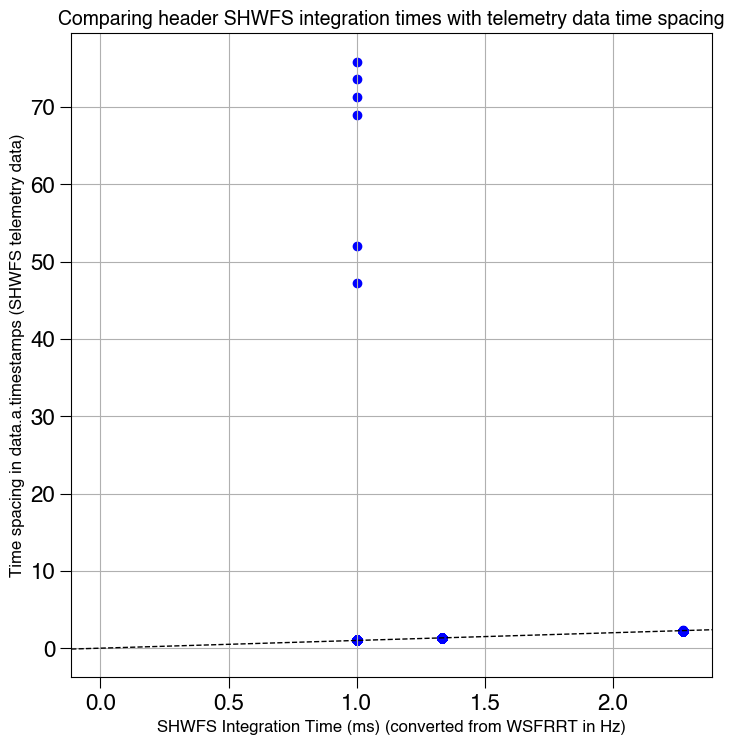

In [44]:
shwfs_times = telemetry['SHWFS int times'].astype(float)
data_a_intervals = telemetry['DATA.A Time Interval'].astype(float)

fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(shwfs_times, data_a_intervals, color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.xlabel("SHWFS Integration Time (ms) (converted from WSFRRT in Hz)", fontsize=12)
plt.ylabel("Time spacing in data.a.timestamps (SHWFS telemetry data)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.title("Comparing header SHWFS integration times with telemetry data time spacing", fontsize=14)
plt.show()

In [45]:
telemetry[round(telemetry['SHWFS int times'].astype(float), 1) != round(telemetry['DATA.A Time Interval'].astype(float), 1)]

,filename,LGRMSWFs,STRAPDQMNs,SUBAPINTs [adu],STINTTIMs,DATA.B Time Interval,SHWFS int times,DATA.A Time Interval,APDCOUNTS,APD_SKY_BACK,SHWFS FLUX,RESIDUALRMS,RMSWFE,STRAP SIGLEV,STRAP BKGRND,SHWFS SIGLEV,SHWFS BKGRND
1467,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,712.9,705783.75,247.65045166015625,1.0,1.0000481726111845,1.0,75.79664187582563,0.5982168912887573,0.0,125.80645751953125,1546.15087890625,1047.6292848587036,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221
1468,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,817.5,673432.75,240.58551025390625,1.0,1.0000481726111845,1.0,73.60216538969618,0.5982168912887573,0.0,122.217529296875,1552.0966796875,1049.804949760437,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221
1469,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,852.3,648249.5,233.1034393310547,1.0,1.0000481726111845,1.0,71.26110337589903,0.5982168912887573,0.0,118.41670227050781,1558.043701171875,1052.0353317260742,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221
1470,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,886.8,616052.5,226.40086364746094,1.0,1.0000481726111845,1.0,68.91969894319683,0.5982168912887573,0.0,115.01161193847656,1563.1435546875,1053.8814067840576,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221
1471,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,267.0,177767.0,175.7158660888672,1.0,1.0000481726111845,1.0,52.09275329517101,0.5982168912887573,0.0,89.2636489868164,1566.0367431640625,1069.8573589324951,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221
1472,/g/lu/data/keck_telemetry/20170809/sdata901/ni...,569.7,149003.25,162.5408477783203,1.0,1.0000481726111845,1.0,47.26365238514605,0.5982168912887573,0.0,82.57074737548828,1532.6002197265625,1072.4600315093994,765.0629274803571,3.9046657458615774,600.3569079404291,0.07122820854882221


In [4]:
cleaned_telem = telemetry[(telemetry['STINTTIMs'].astype(float) == round(telemetry['DATA.B Time Interval'].astype(float), 1)) & (round(telemetry['SHWFS int times'].astype(float), 1) == round(telemetry['DATA.A Time Interval'].astype(float), 1))]

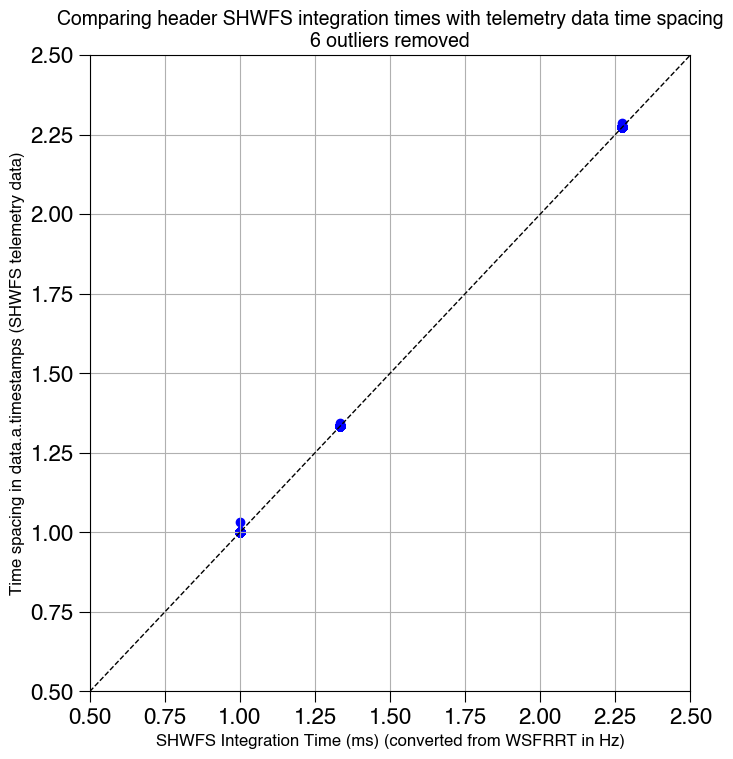

In [47]:
shwfs_times = cleaned_telem['SHWFS int times'].astype(float)
data_a_intervals = cleaned_telem['DATA.A Time Interval'].astype(float)
outliers = telemetry[round(telemetry['SHWFS int times'].astype(float), 1) != round(telemetry['DATA.A Time Interval'].astype(float), 1)].shape[0]

fig, axes = plt.subplots(figsize=(7.5, 7.5))
plt.scatter(shwfs_times, data_a_intervals, color="blue")
# y=x line (desired correlation)
plt.axline((0, 0), (1, 1), linewidth=1, color='black', linestyle="--")
plt.ylim(0.5, 2.5)
plt.xlim(0.5, 2.5)
plt.xlabel("SHWFS Integration Time (ms) (converted from WSFRRT in Hz)", fontsize=12)
plt.ylabel("Time spacing in data.a.timestamps (SHWFS telemetry data)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.title(f"Comparing header SHWFS integration times with telemetry data time spacing\n{outliers} outliers removed", fontsize=14)
plt.show()

#### **Compare LGRMSWF, RESIDUALRMS, and RMSWFE**
``LGRMSWF`` is value from FITS image and ``data`` ``header``s - closed-loop HO wavefront residual [nm]

``RESIDUALRMS`` (see above)

``RMSWFE`` calculated from ``residualwavefront`` telemetry data in ``centroid_residual_to_RMSWFE(...)``
* ** *TO DO* ** : add ``MAOS HO WFE`` (computed from MAOS)

##### Scatter plot

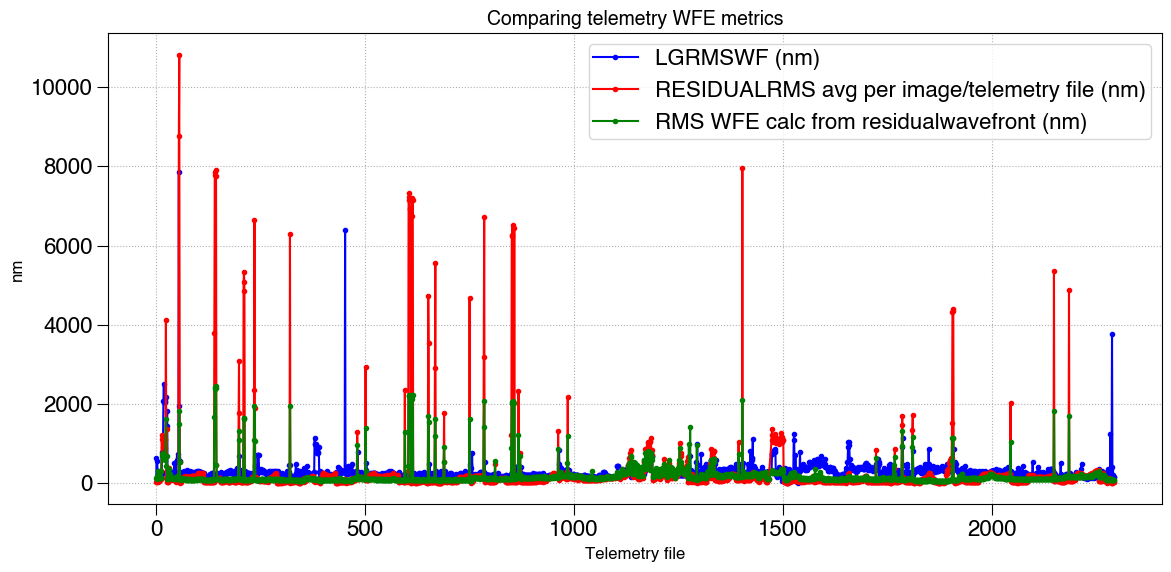

In [53]:
fig, axes = plt.subplots(figsize=(12, 6))
plt.plot(cleaned_telem['LGRMSWFs'].astype(float), '.-', color="blue", label="LGRMSWF (nm)")
# RESIDUALRMS is in Volts according to updated KAON, so convert to microns, then to nm
plt.plot(cleaned_telem['RESIDUALRMS'].astype(float), '.-', color="red", label="RESIDUALRMS avg per image/telemetry file (nm)")
plt.plot(cleaned_telem['RMSWFE'].astype(float), '.-', color="green", label="RMS WFE calc from residualwavefront (nm)")
plt.title("Comparing telemetry WFE metrics", fontsize=14)
plt.xlabel("Telemetry file", fontsize=12)
plt.ylabel("nm", fontsize=12)
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='dotted')
# plt.ylim(0.0, 3000.0)
plt.show()

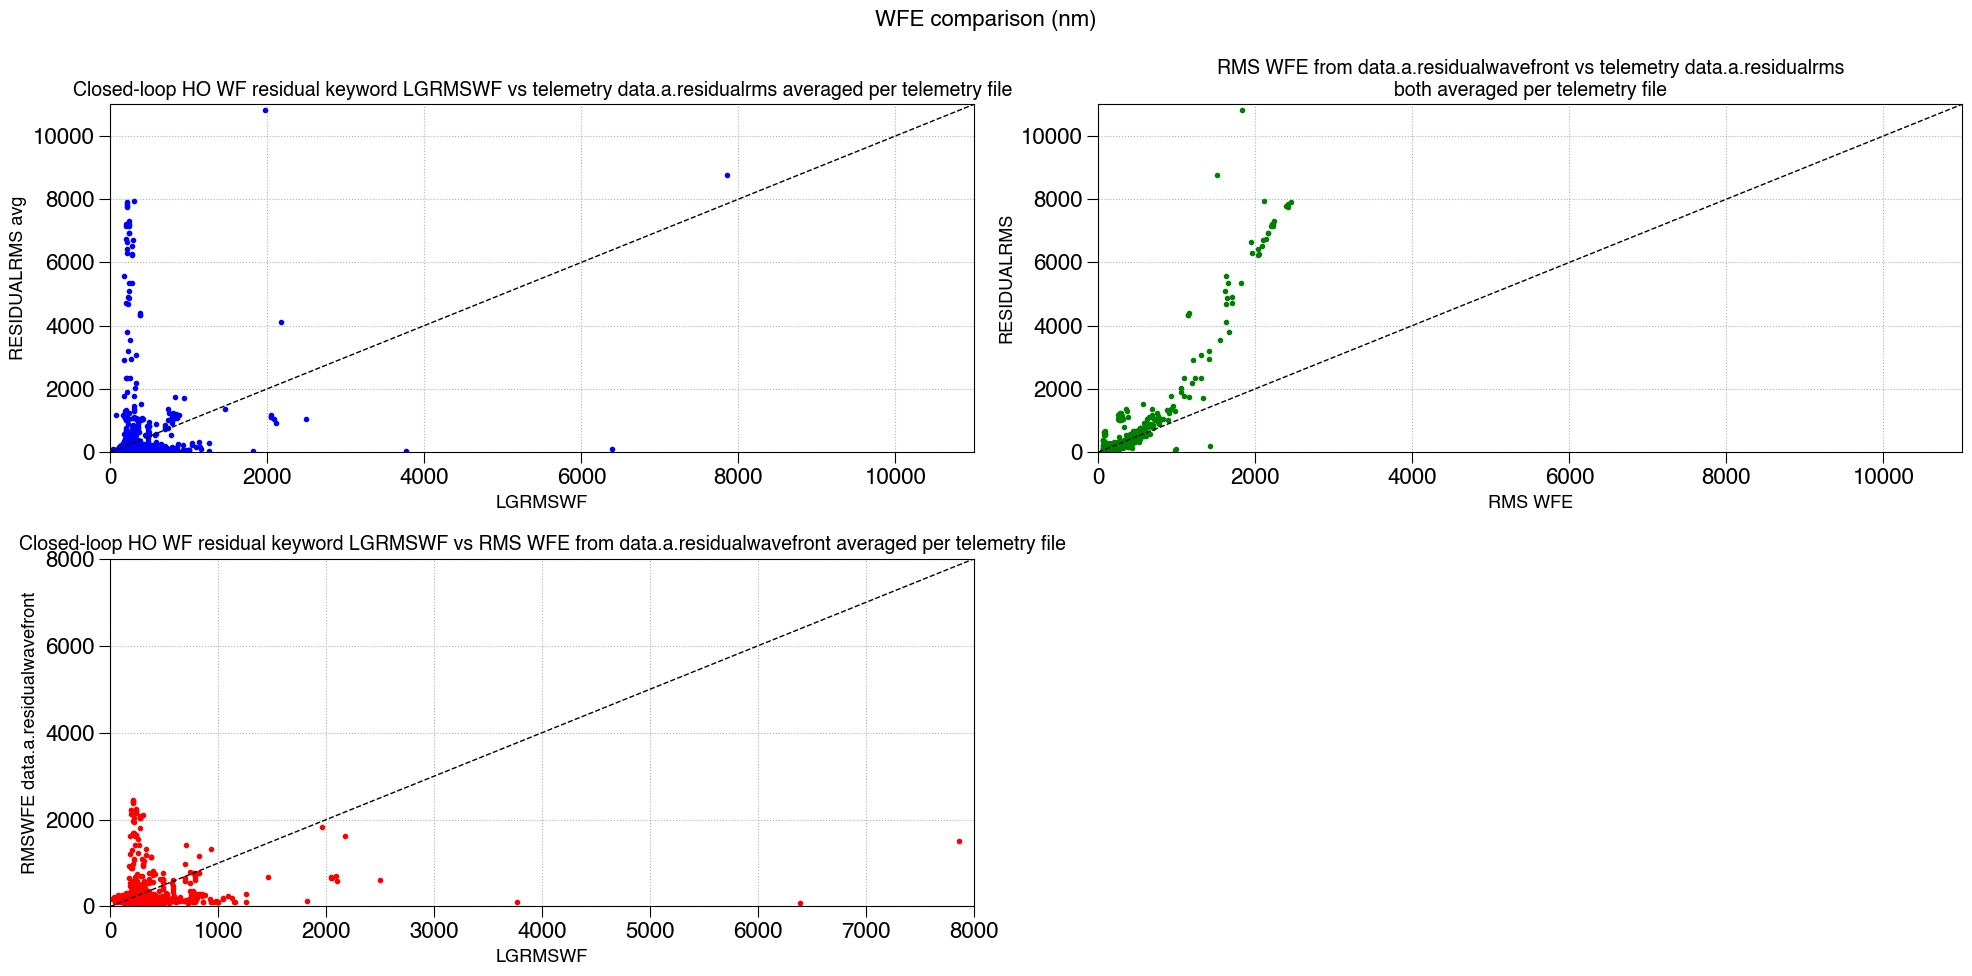

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes[0, 0].plot(cleaned_telem['LGRMSWFs'].astype(float), cleaned_telem['RESIDUALRMS'].astype(float), '.', color="blue")
axes[1, 0].plot(cleaned_telem['LGRMSWFs'].astype(float), cleaned_telem['RMSWFE'].astype(float), '.', color="red")
axes[0, 1].plot(cleaned_telem['RMSWFE'].astype(float), cleaned_telem['RESIDUALRMS'].astype(float), '.', color="green")
axes[1, 1].remove()
axes[0, 0].set_title("Closed-loop HO WF residual keyword LGRMSWF vs telemetry data.a.residualrms averaged per telemetry file", fontsize=14)
axes[0, 0].set_xlabel("LGRMSWF", fontsize=13)
axes[0, 0].set_ylabel("RESIDUALRMS avg", fontsize=13)
axes[1, 0].set_title("Closed-loop HO WF residual keyword LGRMSWF vs RMS WFE from data.a.residualwavefront averaged per telemetry file", fontsize=14)
axes[1, 0].set_xlabel("LGRMSWF", fontsize=13)
axes[1, 0].set_ylabel("RMSWFE data.a.residualwavefront", fontsize=13)
axes[0, 1].set_title("RMS WFE from data.a.residualwavefront vs telemetry data.a.residualrms\nboth averaged per telemetry file", fontsize=14)
axes[0, 1].set_xlabel("RMS WFE", fontsize=13)
axes[0, 1].set_ylabel("RESIDUALRMS", fontsize=13)
axes[0, 0].grid(True, linestyle='dotted')
axes[0, 1].grid(True, linestyle='dotted')
axes[1, 0].grid(True, linestyle='dotted')
axes[0, 0].axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
axes[0, 1].axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
axes[1, 0].axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
axes[0, 0].set_xlim(0.0, 11000.0)
axes[0, 0].set_ylim(0.0, 11000.0)
axes[0, 1].set_xlim(0.0, 11000.0)
axes[0, 1].set_ylim(0.0, 11000.0)
axes[1, 0].set_xlim(0.0, 8000.0)
axes[1, 0].set_ylim(0.0, 8000.0)
plt.suptitle("WFE comparison (nm)", fontsize=16)
plt.tight_layout()
plt.show()

##### Histogram

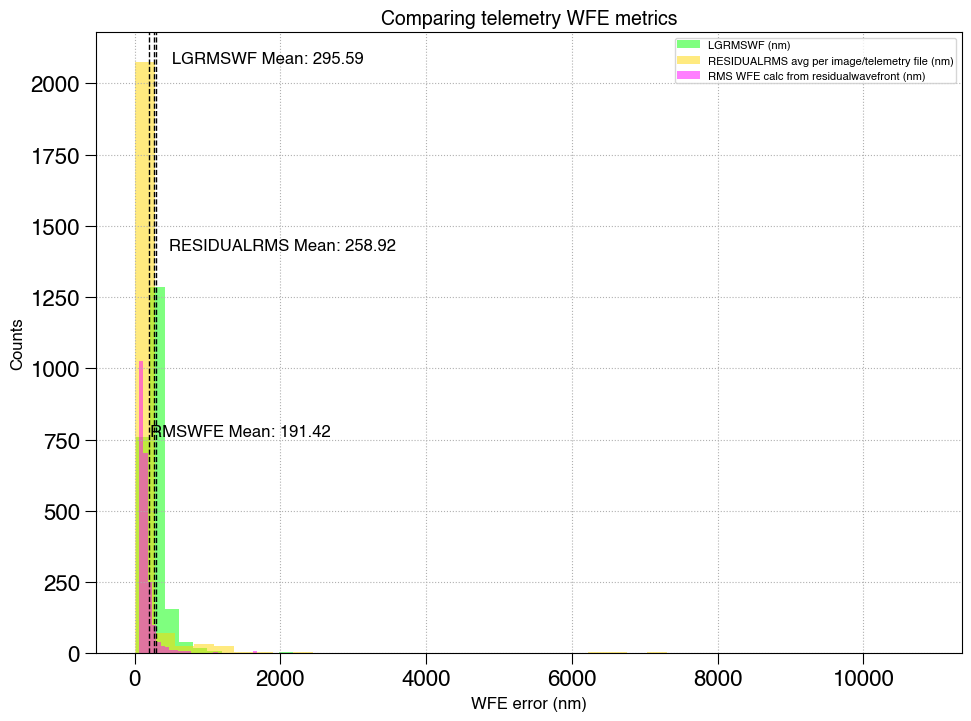

In [52]:
fig, axes = plt.subplots(figsize=(10.0, 7.5))
plt.hist(cleaned_telem['LGRMSWFs'].astype(float), bins=40, color="lime", alpha=0.5, label="LGRMSWF (nm)")
plt.hist(cleaned_telem['RESIDUALRMS'].astype(float), bins=40, color="gold", alpha=0.5, label="RESIDUALRMS avg per image/telemetry file (nm)")
plt.hist(cleaned_telem['RMSWFE'].astype(float), bins=40, color="magenta", alpha=0.5, label="RMS WFE calc from residualwavefront (nm)")
plt.title("Comparing telemetry WFE metrics", fontsize=14)
plt.xlabel("WFE error (nm)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.legend(fontsize=8)
plt.tight_layout()
min_ylim, max_ylim = plt.ylim()
plt.text(cleaned_telem['LGRMSWFs'].astype(float).mean()*1.1, max_ylim*0.95, 
         '\t\t\tLGRMSWF Mean: {:.2f}'.format(cleaned_telem['LGRMSWFs'].astype(float).mean()),
         fontsize=12)
plt.axvline(cleaned_telem['LGRMSWFs'].astype(float).mean(), color='k', 
            linestyle='dashed', linewidth=1)
plt.text(cleaned_telem['RESIDUALRMS'].astype(float).mean()*1.1, max_ylim*0.65, 
         '\t\t\tRESIDUALRMS Mean: {:.2f}'.format(cleaned_telem['RESIDUALRMS'].astype(float).mean()),
         fontsize=12)
plt.axvline(cleaned_telem['RESIDUALRMS'].astype(float).mean(), color='k', 
            linestyle='dashed', linewidth=1)
plt.text(cleaned_telem['RMSWFE'].astype(float).mean()*1.1, max_ylim*0.35, 
         'RMSWFE Mean: {:.2f}'.format(cleaned_telem['RMSWFE'].astype(float).mean()),
         fontsize=12)
plt.axvline(cleaned_telem['RMSWFE'].astype(float).mean(), color='k', 
            linestyle='dashed', linewidth=1)
plt.grid(True, linestyle='dotted')
plt.show()

#### **Compare ``APD_SKY_BACK`` with ``powfs.bkgrnd[STRAP]``**
units unclear because ``APD_SKY_BACK`` is not defined in the telemetry KAON, so it is not clear if the ``STRAP`` background input into ``MAOS`` has the same units

In [72]:
apd_bkgrnds = cleaned_telem['APD_SKY_BACK'].astype(float)
strap_bkgrnd = cleaned_telem['STRAP BKGRND'].astype(float) # sky background in e/pixel/frame at integration time sim.dtref

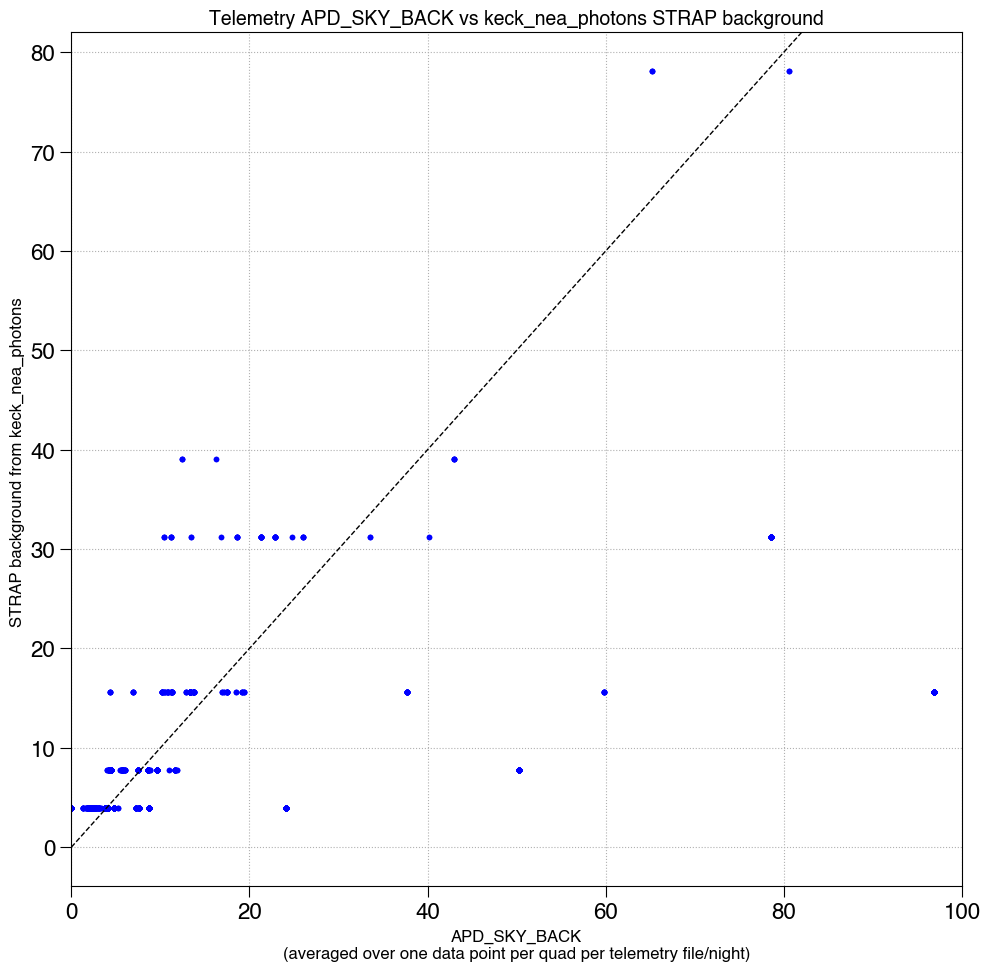

In [73]:
fig, axes = plt.subplots(figsize=(10, 10))
plt.plot(apd_bkgrnds, strap_bkgrnd, '.', color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
plt.title("Telemetry APD_SKY_BACK vs keck_nea_photons STRAP background", fontsize=14)
plt.xlabel("APD_SKY_BACK\n(averaged over one data point per quad per telemetry file/night)", fontsize=12)
plt.ylabel("STRAP background from keck_nea_photons ", fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='dotted')
plt.xlim(0.0, 100.0)
plt.show()

#### **Compare ``keck_nea_photon(...)`` output for ``MAOS`` input ``powfs.siglev[SHWFS, STRAP]`` to ``STRAPDQMN`` and ``SUBAPINTENSITY`` telemetry**

In [74]:
strap_siglev = cleaned_telem['STRAP SIGLEV'].astype(float) # units in MAOS unclear, MAOS performance doc gives 'Signal level in e- per subaperture per exposure at integration time sim.dtref for each WFS'
shwfs_siglev = cleaned_telem['SHWFS SIGLEV'].astype(float) # units in MAOS unclear
shwfs_bkgrnd = cleaned_telem['SHWFS BKGRND'].astype(float) # sky background in e/pixel/frame at integration time sim.dtref

#### **APDCOUNTS and STRAPDQMN comparison to investigate unknown gain settings**

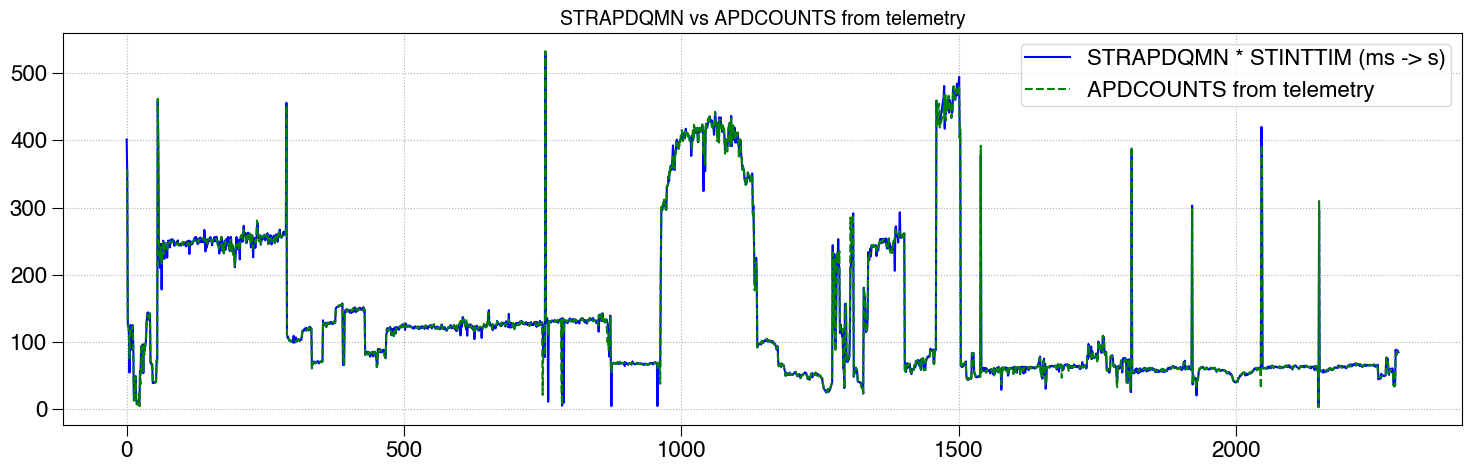

In [75]:
fig, axes = plt.subplots(figsize=(15, 5))
plt.plot(cleaned_telem['STRAPDQMNs'].astype(float)*cleaned_telem['STINTTIMs'].astype(float)*0.001, label="STRAPDQMN * STINTTIM (ms -> s)", color="blue")
plt.plot(cleaned_telem['APDCOUNTS'].astype(float), label="APDCOUNTS from telemetry", color="green", linestyle="--")
plt.title("STRAPDQMN vs APDCOUNTS from telemetry", fontsize=14)
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='dotted')
plt.show()

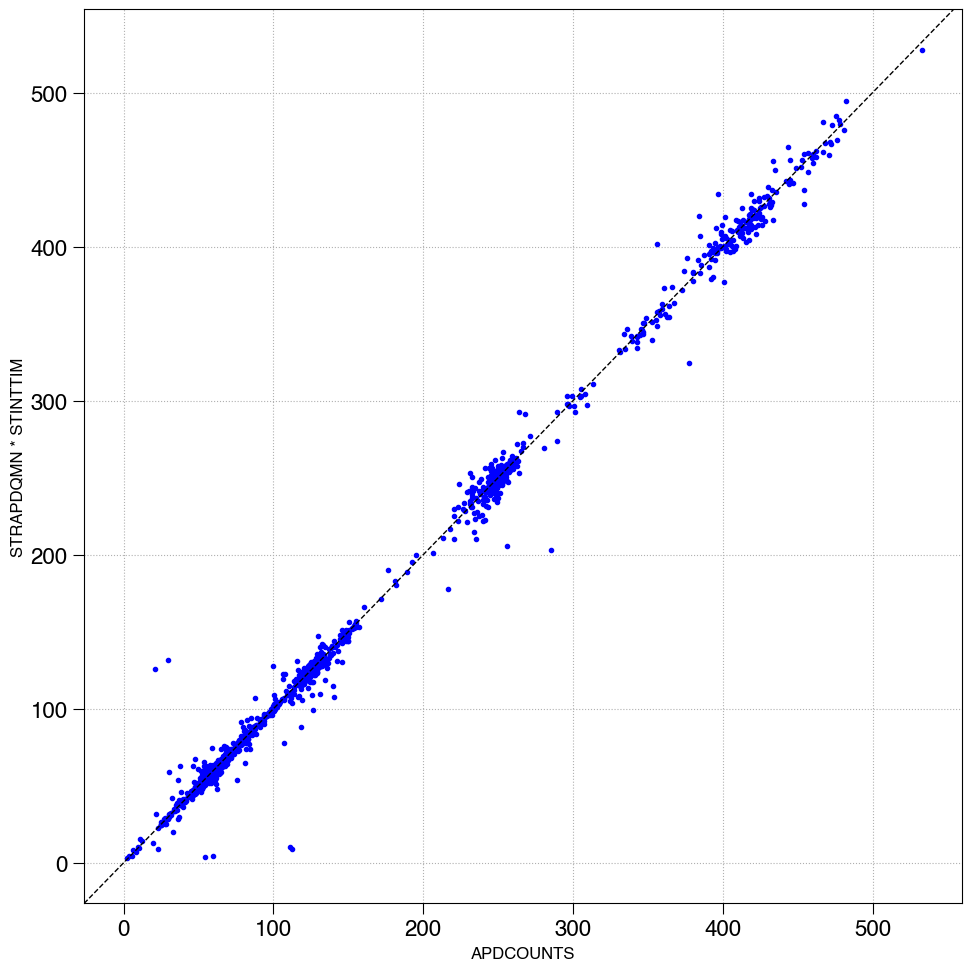

In [76]:
fig, axes = plt.subplots(figsize=(10, 10))
plt.plot(cleaned_telem['APDCOUNTS'].astype(float), cleaned_telem['STRAPDQMNs'].astype(float)*cleaned_telem['STINTTIMs'].astype(float)*0.001, '.', color="blue")
plt.axline((0, 0), (1, 1), linewidth=1, linestyle="--", color="black")
plt.xlabel("APDCOUNTS", fontsize=12)
plt.ylabel("STRAPDQMN * STINTTIM", fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='dotted')
plt.show()

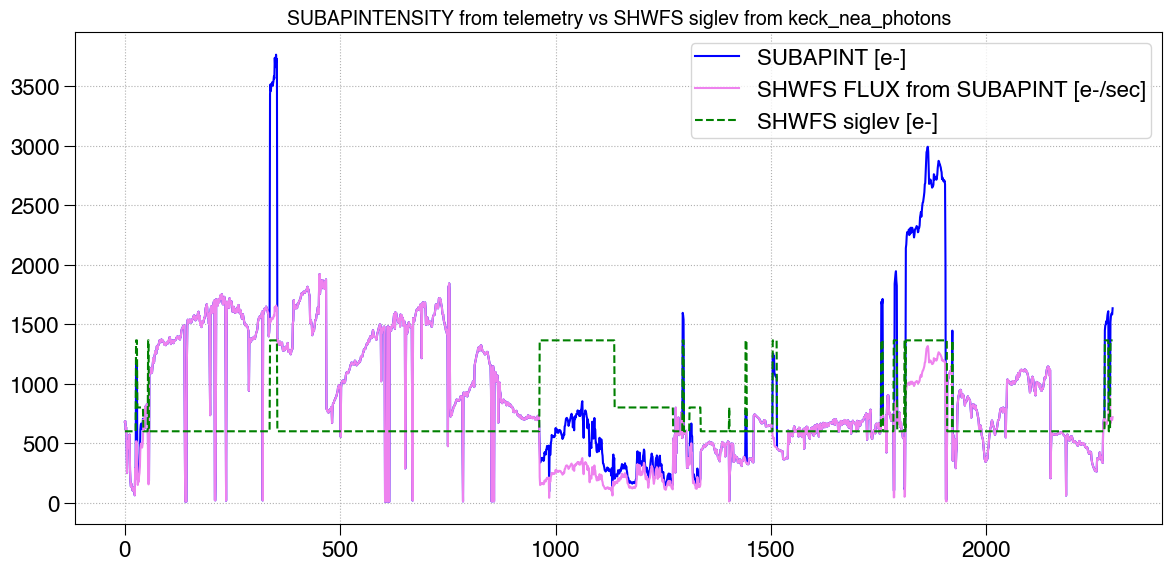

In [80]:
fig, axes = plt.subplots(figsize=(12, 6))
# multiply by gain from KAON 387
plt.plot(cleaned_telem['SUBAPINTs [adu]'].astype(float)*0.508, label="SUBAPINT [e-]", color="blue")
plt.plot(cleaned_telem['SHWFS FLUX'].astype(float), label="SHWFS FLUX from SUBAPINT [e-/sec]", color="violet")
plt.plot(cleaned_telem['SHWFS SIGLEV'].astype(float), label="SHWFS siglev [e-]", color="green", linestyle="--")
plt.title("SUBAPINTENSITY from telemetry vs SHWFS siglev from keck_nea_photons", fontsize=14)
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='dotted')
plt.show()

### **MAOS TT WFE versus TT residual error from telemetry**

In [31]:
n0058 = readsav(telemetry['filename'][1517])
n0058_tt_residual = n0058.b.dttcentroids[0] * (1/0.009952) #px/arcsec, 
# multiply by residuals to get residuals in px, 
# then convert pixels to microns --> nm for comparison with MAOS WFE
n0058_tt_residual *= 21 # microns (1 pixel = 21 micron)
n0058_tt_residual *= 1000.0 # microns to nm
n0058_tt_residual_x = n0058_tt_residual[:,0]
n0058_tt_residual_y = n0058_tt_residual[:,1]

In [34]:
# average over timestream
print(f"Average x TT residual = {np.mean(n0058_tt_residual_x)} nm")
print(f"Average y TT residual = {np.mean(n0058_tt_residual_y)} nm")

Average x TT residual = -79.24864959716797 nm
Average y TT residual = 560.74951171875 nm


In [43]:
# LGRMSWF values to compare to HO MAOS errors below
for item in n0058.header:
    decoded:str = item.decode('ascii')
    # LGRMSWF = closed-loop HO RMS WF residual for the night of telemetry
    if decoded.startswith('LGRMSWF'):
        lgrmswf = decoded.split(' ')[2]
        print(f"LGRMSWF (nm) = {lgrmswf[1:]}")

LGRMSWF (nm) = 253.5


In [46]:
avg_rmswfe_n0058, _, _ = mu.centroid_residual_to_RMSWFE(telem_path=Path(telemetry['filename'][1517]))
print(f"RMS WFE calculated from telemetry centroid offsets (nm) = {avg_rmswfe_n0058}")

RMS WFE calculated from telemetry centroid offsets (nm) = 624.9082641601562


In [41]:
# MAOS TT WFE
seeds = [1, 1000, 5000, 10000]
mu.collect_maos_results(seeds=np.array(seeds), 
                        framedates=np.array([['c2058', '20170823']], dtype=str), 
                        baseroot=Path('/Users/bdigia/work/ao/keck/maos/keck/my_base/'),
                        simtype='piston')

/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_piston_comp_c2058_seed1_epoch20170823/evlpsfcl_1_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742008033162 | Scale = 0.0200277 arcsec/px
FWHM on iteration 1 = 50.57 mas | Empirical FWHM on iteration 1 = 50.53 mas
Looking in directory: /Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_piston_comp_c2058_seed1_epoch20170823/
---------------------
WaveFront Error (nm): [note, piston removed from all]
---------------------
Field Avg        Total   High_Order           TT
---------  -----------   ----------   ----------
Open            1652.7        852.4       1415.9
Closed           334.8        260.6        210.3

Pos  0 
-------  
Open            1652.7        852.4       1415.9
Closed           334.8        260.6        210.3
/Users/bdigia/work/ao/keck/maos/keck/my_base/A_keck_scao_lgs_gc_piston_comp_c2058_seed1000_epoch20170823/evlpsfcl_1000_x0_y0.fits
Diffraction-limited resolution [px] = 2.5250742

(array([nan]),
 array([nan]),
 array([nan]),
 array([nan]),
 array([nan]),
 array([nan]),
 [338.14963136028666],
 [257.28699392646536],
 [219.3161962755245],
 array([52944.0833151]),
 array([2411.54210384]))

In [ ]:
# Marcos van Dam equation

### **Cloud cover check**

sum up STRAP ADP channels and plot over telemetry timestream. If this is constant then STRAP didn't see many clouds --> no cloud cover. Also compare to the SHWFS timestream

In [6]:
cloud_sample = readsav(telemetry['filename'][26])
cloud_sample.b.apdcounts[0].shape

(8226, 4)

In [7]:
four_channel_sum = np.sum(cloud_sample.b.apdcounts[0], axis=1)

In [8]:
subapint_avg_over_actuators = np.mean(cloud_sample.a.subapintensity[0], axis=1)

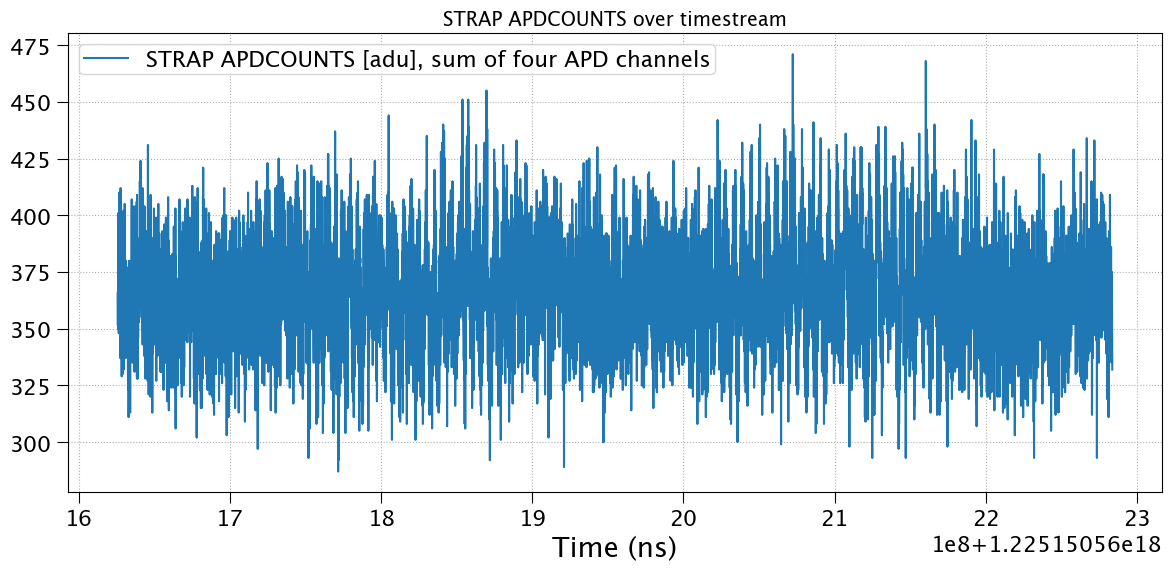

In [9]:
fig, axes = plt.subplots(figsize=(12, 6))
plt.plot(cloud_sample.b.timestamp[0], four_channel_sum, label="STRAP APDCOUNTS [adu], sum of four APD channels")
plt.title("STRAP APDCOUNTS over timestream", fontsize=14)
plt.xlabel("Time (ns)")
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle='dotted')
plt.show()

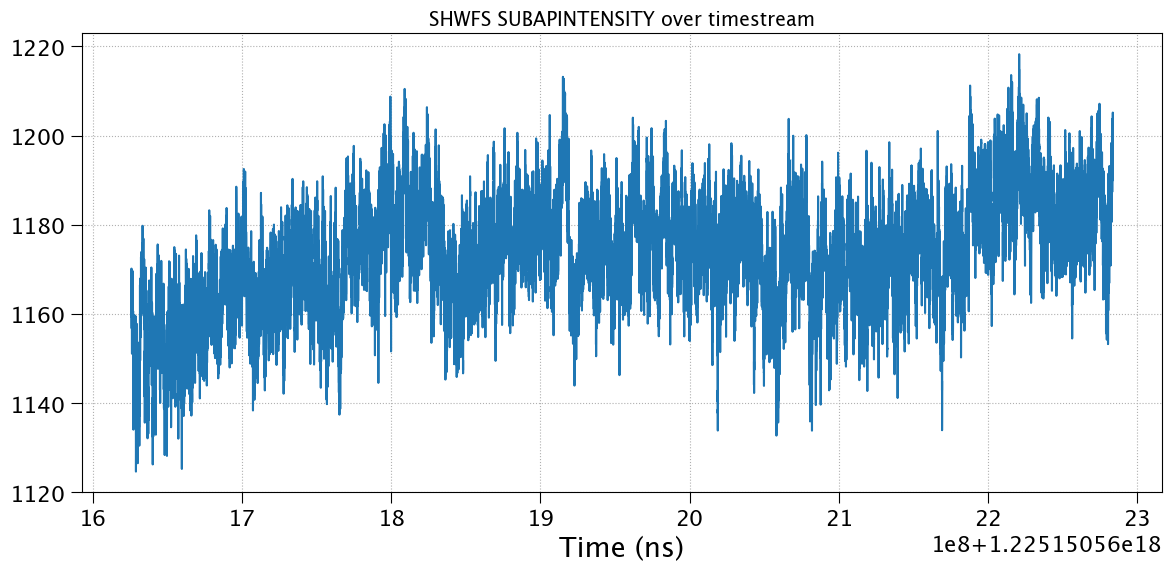

In [13]:
fig, axes = plt.subplots(figsize=(12, 6))
# plt.plot(cloud_sample.a.timestamp[0], cloud_sample.a.subapintensity[0])
plt.plot(cloud_sample.a.timestamp[0], subapint_avg_over_actuators*0.508)
plt.title("SHWFS SUBAPINTENSITY over timestream", fontsize=14)
plt.xlabel("Time (ns)")
plt.tight_layout()
plt.grid(True, linestyle='dotted')
plt.show()

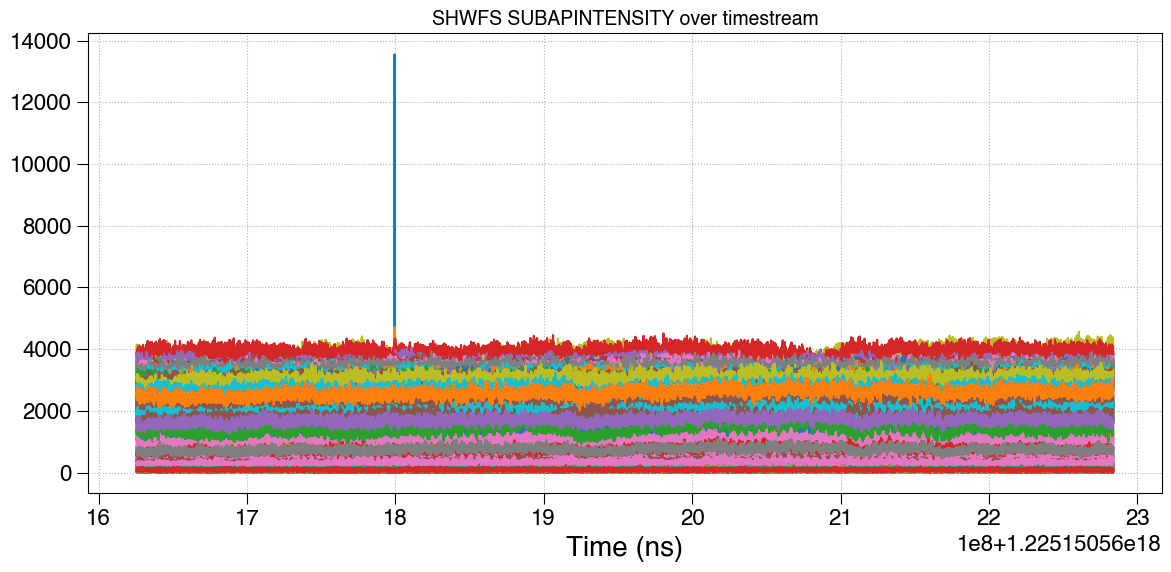

In [57]:
fig, axes = plt.subplots(figsize=(12, 6))
plt.plot(cloud_sample.a.timestamp[0], cloud_sample.a.subapintensity[0])
plt.title("SHWFS SUBAPINTENSITY over timestream", fontsize=14)
plt.xlabel("Time (ns)")
plt.tight_layout()
plt.grid(True, linestyle='dotted')
plt.show()